## Importação de bibliotecas, upload das imagens e função de cálculo do histograma

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
arquivo = files.upload()

Saving clara.jpg to clara.jpg
Saving normal.jpg to normal.jpg
Saving escura.jpg to escura.jpg


In [7]:
def calHist(img):
  hist_arr = np.zeros(256, dtype=int)
  for px in img:
    hist_arr[px] += 1
  plt.bar(range(256), hist_arr)

## Conversão para cinza e plotagem dos histogramas

In [8]:
clara_rgb = cv2.imread('clara.jpg', cv2.IMREAD_COLOR_RGB)
clara_gray = cv2.cvtColor(clara_rgb, cv2.COLOR_RGB2GRAY)
normal_rgb = cv2.imread('normal.jpg', cv2.IMREAD_COLOR_RGB)
normal_gray = cv2.cvtColor(normal_rgb, cv2.COLOR_RGB2GRAY)
escura_rgb = cv2.imread('escura.jpg', cv2.IMREAD_COLOR_RGB)
escura_gray = cv2.cvtColor(escura_rgb, cv2.COLOR_RGB2GRAY)

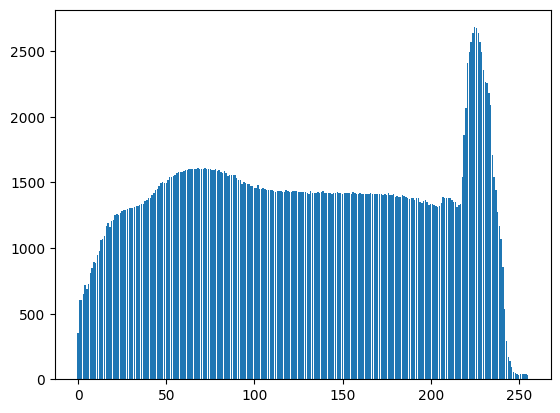

In [11]:
calHist(clara_gray)

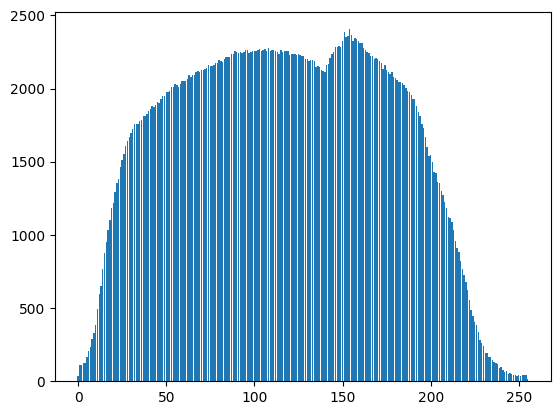

In [12]:
calHist(normal_gray)

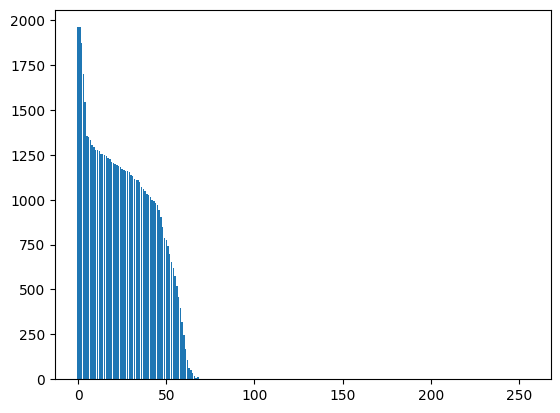

In [13]:
calHist(escura_gray)

- **Imagem clara (clara_gray):** As intensidades estão fortemente concentradas na faixa de 220-245, indicando que a imagem é predominantemente muito brilhante, com muitos pixels próximos ao branco.
- **Imagem normal (normal_gray):** As intensidades estão bem distribuídas ao longo de quase todo o espectro, sugerindo uma imagem com bom contraste e uma gama equilibrada de tons, sem áreas excessivamente claras ou escuras.
- **Imagem escura (escura_gray):** Há uma concentração significativa das intensidades na faixa de 0-60, o que revela que a imagem é predominantemente escura, com muitos pixels próximos ao preto e pouca variação nos tons mais claros.

## Equalização de Histograma

/tmp/ipykernel_5378/2623379841.py:16: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(original_img.ravel(), 256, [0, 256])
/tmp/ipykernel_5378/2623379841.py:25: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(processed_img.ravel(), 256, [0, 256])


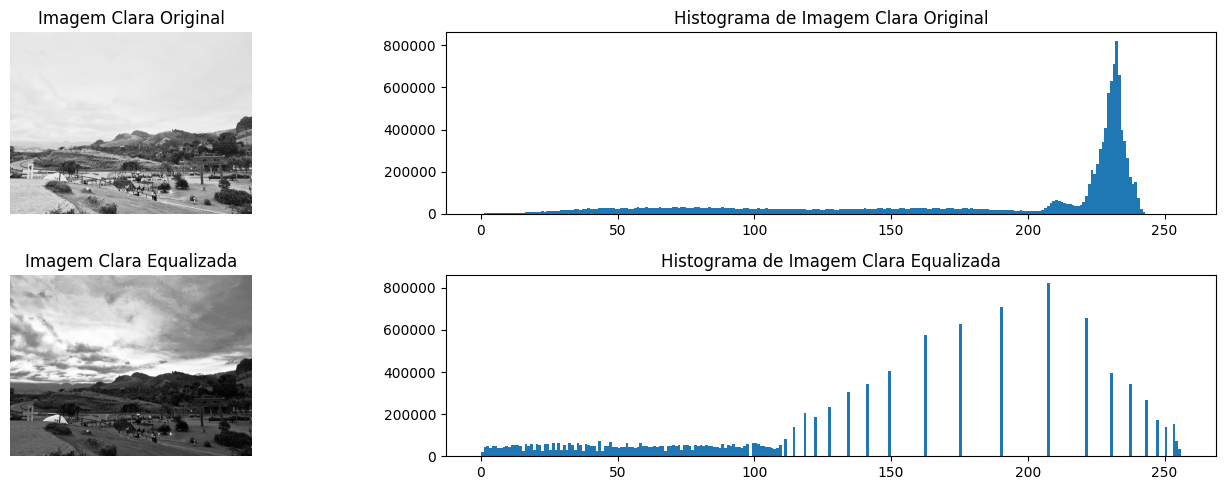

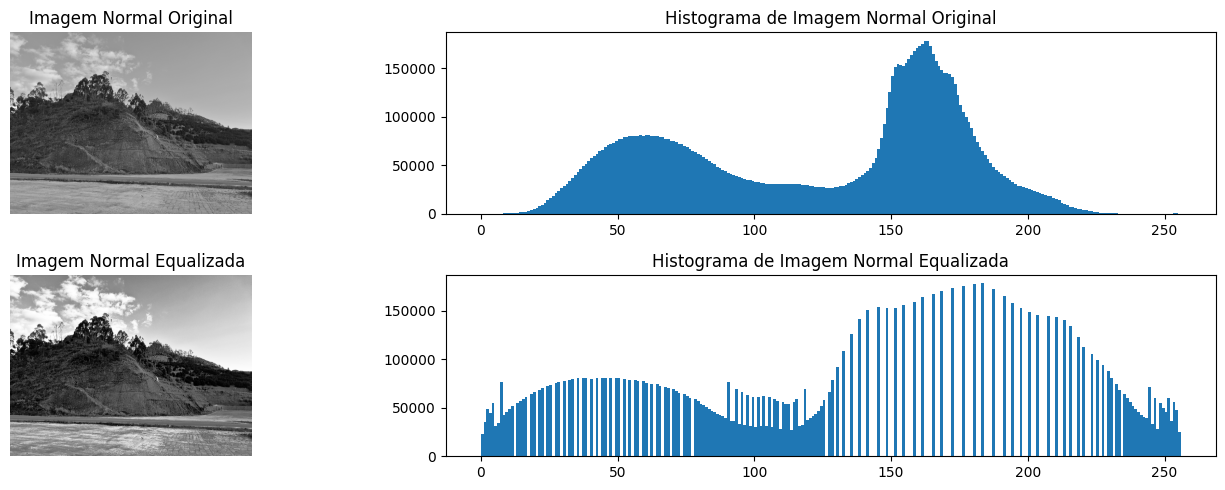

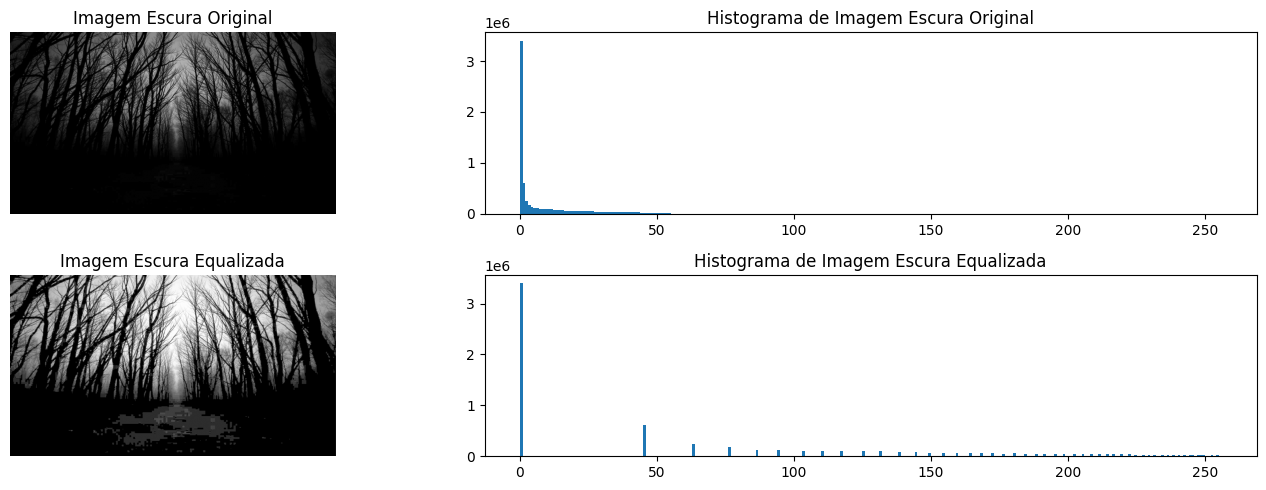

In [14]:
clara_eq = cv2.equalizeHist(clara_gray)
normal_eq = cv2.equalizeHist(normal_gray)
escura_eq = cv2.equalizeHist(escura_gray)

def display_image_and_hist(original_img, processed_img, title_original, title_processed):
    plt.figure(figsize=(15, 5))

    plt.subplot(2, 2, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title(title_original)
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.hist(original_img.ravel(), 256, [0, 256])
    plt.title(f'Histograma de {title_original}')

    plt.subplot(2, 2, 3)
    plt.imshow(processed_img, cmap='gray')
    plt.title(title_processed)
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.hist(processed_img.ravel(), 256, [0, 256])
    plt.title(f'Histograma de {title_processed}')

    plt.tight_layout()
    plt.show()

display_image_and_hist(clara_gray, clara_eq, 'Imagem Clara Original', 'Imagem Clara Equalizada')

display_image_and_hist(normal_gray, normal_eq, 'Imagem Normal Original', 'Imagem Normal Equalizada')

display_image_and_hist(escura_gray, escura_eq, 'Imagem Escura Original', 'Imagem Escura Equalizada')

## Resumo da Equalização de Histograma
A equalização de histograma demonstrou ser uma técnica eficaz para otimizar o contraste das imagens, redistribuindo as intensidades de pixel. Na **imagem clara**, recuperou detalhes em áreas "estouradas"; na **imagem escura**, revelou informações antes ocultas nas sombras; e na **imagem normal**, manteve um bom equilíbrio de contraste, com otimização sutil. A principal vantagem é a sua capacidade de adaptar-se automaticamente à distribuição de brilho de cada imagem.

### Imagem com menor diferença após Equalização

A equalização de histograma fez menos diferença na **imagem normal** (normal_gray). Isso ocorreu porque o seu histograma já apresentava uma distribuição de intensidades relativamente equilibrada em comparação com as imagens clara e escura. Como a imagem normal já possuía um bom contraste e uma boa distribuição tonal, o impacto visual da equalização foi menos dramático, resultando em melhorias mais sutis do que nas outras duas imagens.